# Kotitehtävä 2

### Tarvittavat Importit

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [23]:
def ReLU(x):
    return np.maximum(0, x)

def softmax(x):
    y = np.exp(x)
    return y / np.sum(y, axis=0)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

## Tehtävä 1

Tehtävässä on annettu alkuvektori $A_0$ sekä kerroinmatriisit $W_1$ ja $W_2$. Tavoitteena on laskea vektorit $A_1$ ja $A_2$ matriisikertolaskujen avulla. Bias-termejä tai aktivaatiofunktioita ei tässä vaiheessa käytetä.

Kaavat: $A_1 = W_1 A_0$ ja $A_2 = W_2 A_1$

In [ ]:
# Määritellään matriisit ja alkuvektori
A0 = np.array([
    [3],
    [2],
    [5]
])
W1 = np.array([[1.1, -1.3, 1.5], [0.1, 2.0, 1.7]])
W2 = np.array([2.0, -1.2])

In [ ]:
# Lasketaan A1 ja A2 matriisikertolaskulla
A1 = W1 @ A0
A2 = W2 @ A1

print("Vektori A1:", [[float(x)] for x in A1.flatten()])
print("Vektori A2:", ", ".join(f"[{x:.2f}]" for x in A2))

Vektori A1: [[8.2], [12.8]]
Vektori A2: [1.04]


## Tehtävä 2 

Lisätään verkkoon aktivaatiofunktiot. Ensimmäiselle kerrokselle käytetään ReLU-funktiota $f(x)$ ja toiselle kerrokselle sigmoid-funktiota $g(x)$. 

Kaavat: $A_1 = f(W_1 A_0)$ ja $A_2 = g(W_2 A_1)$

ReLU palauttaa negatiivisille arvoille 0 ja positiivisille luvun itsensä. Sigmoid puristaa lopputuloksen välille 0 ja 1. Odotettu lopputulos korjaustiedotteen mukaisesti on noin 0.73885.

In [56]:
new_A1 = []

for i in range(A1.size):
    rivi = []
    for j in range(A1[i].size):
        if A1[i][j] < 0:
            new_A1.append(0)
        else:
            rivi.append(A1[i][j])
    new_A1.append(rivi)

A1_relu = np.array(new_A1)
print(A1_relu)

print(sigmoid(A2))

[[ 8.2]
 [12.8]]
[[[[0.73885001]]]]


## Tehtävä 3

Annettuun dataan sovitetaan suora yhtälöllä $\hat{y}_i = \theta_0 + \theta_1 x_i$. 

Regressiokertoimet matriisimuodossa ratkaistaan kaavalla:
$M = (X^T X)^{-1} X^T Y$

Muodostetaan vaaditut pystyvektorit sekä matriisi $X$, johon on lisätty ykkössarake vakiotermiä varten. Lopuksi piirretään datapisteet ja sovitettu regressiosuora kuvaajaan.

Regressiokertoimet (M):
[[10.6       ]
 [ 4.76363636]]


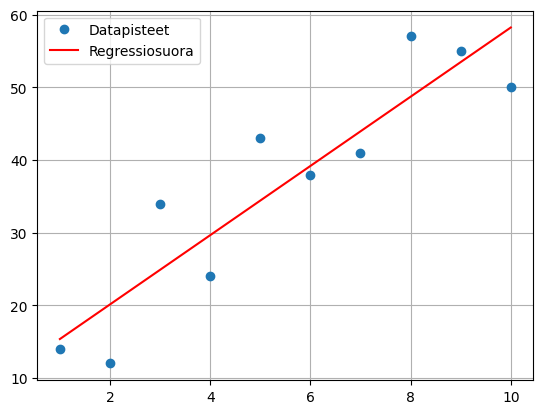

In [ ]:
# Datan määrittely 10x1 pystyvektoreiksi
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
Y = np.array([14, 12, 34, 24, 43, 38, 41, 57, 55, 50]).reshape(-1, 1)

# Muodostetaan 10x2 matriisi X = [1 x]
X = np.hstack((np.ones((10, 1)), x))

# Ratkaistaan kertoimet M = (X^T X)^-1 X^T Y
M = np.linalg.inv(X.T @ X) @ X.T @ Y

print("Regressiokertoimet (M):")
print(M)

xx = np.linspace(1, 10, 1000).reshape(-1, 1)

# Luodaan XX samalla tavalla kuin X aiemmin
XX = np.hstack((np.ones((1000, 1)), xx))

# Lasketaan y-arvot suoralle
yy = XX.dot(M)

plt.plot(x, Y, 'o', label='Datapisteet')
plt.plot(xx, yy, '-', label='Regressiosuora', color='red')
plt.legend()
plt.grid(True)
plt.show()

## Tehtävä 4

Tässä tehtävässä sovitetaan tehtävän 3 dataan toisen asteen polynomi yhtälöllä $\hat{y}_i = \theta_0 + \theta_1 x_i + \theta_2 x_i^2$.

Tämä tehdään laajentamalla matriisia $X$ uudella sarakkeella $x^2$, jolloin matriisista $X$ tulee $10 \times 3$ kokoinen. Regressiokertoimet $M$ lasketaan samalla matriisiyhtälöllä kuin aiemmin lineaarisen regression tapauksessa:
$M = (X^T X)^{-1} X^T Y$

Regressiokertoimet (M_poly):
[[ 2.93333333]
 [ 8.5969697 ]
 [-0.34848485]]


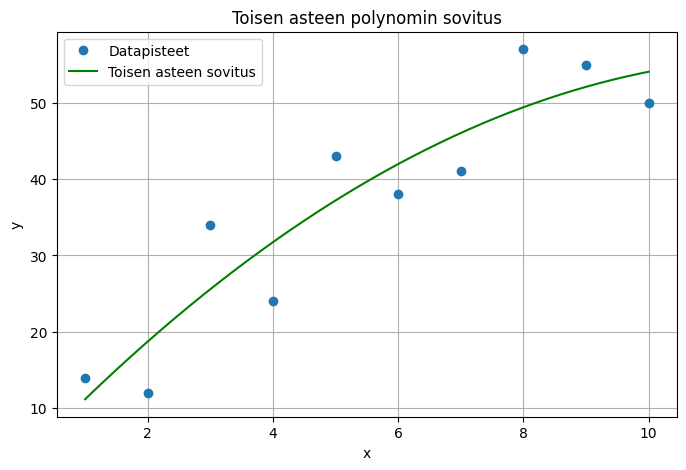

In [97]:
# Luodaan uusi pystyvektori x^2
x_squared = x**2

# Muodostetaan 10x3 matriisi X = [1 x x^2]
X_poly = np.hstack((np.ones((10, 1)), x, x_squared))

# Ratkaistaan kertoimet M = (X^T X)^-1 X^T Y
M_poly = np.linalg.inv(X_poly.T @ X_poly) @ X_poly.T @ Y

print("Regressiokertoimet (M_poly):")
print(M_poly)

# Luodaan x-akselin arvot käyrän piirtämistä varten
xx_squared = xx**2

# Luodaan vastaava 1000x3 matriisi käyrän pisteille
XX_poly = np.hstack((np.ones((1000, 1)), xx, xx_squared))

# Lasketaan y-arvot toisen asteen käyrälle (yy = XX * M)
yy_poly = XX_poly @ M_poly

plt.figure(figsize=(8, 5))
plt.plot(x, Y, 'o', label='Datapisteet')
plt.plot(xx, yy_poly, '-', color='green', label='Toisen asteen sovitus')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Toisen asteen polynomin sovitus')
plt.legend()
plt.grid(True)
plt.show()